In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, matthews_corrcoef, roc_auc_score, 
                             average_precision_score)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# 1. Load the dataset
# Ensure dataset.csv is in the same directory
df = pd.read_csv('dataset.csv')

# 2. Define Features (Handcrafted features from the article)
feature_cols = [
    'duration', 'len', 'mean', 'var', 'std', 'kurtosis', 'skew',
    'n_peaks', 'smooth10_n_peaks', 'smooth20_n_peaks',
    'diff_peaks', 'diff2_peaks', 'diff_var', 'diff2_var',
    'gaps_squared', 'len_weighted', 'var_div_duration', 'var_div_len'
]

# 3. Split into Training (T) and Test (Psi) sets
# The article specifies using the 'train' column for the split
train_df = df[df['train'] == 1].copy()
test_df = df[df['train'] == 0].copy()

X_train = train_df[feature_cols]
y_train = train_df['anomaly']  # 1 = Anomaly, 0 = Nominal
X_test = test_df[feature_cols]
y_test = test_df['anomaly']

# 4. Preprocessing
# Impute missing values (if any) and Scale features
imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train_clean = imputer.fit_transform(X_train)
X_test_clean = imputer.transform(X_test)

X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

# ==========================================
# Model 1: Isolation Forest (Unsupervised)
# ==========================================
# The article specifies a contamination factor of 0.2 for unsupervised baselines
print("Training Isolation Forest (Unsupervised)...")
iso_forest = IsolationForest(contamination=0.2, random_state=42, n_jobs=-1)
iso_forest.fit(X_train_scaled)

# Predictions: -1 is outlier, 1 is inlier. We map -1 -> 1 (Anomaly)
y_pred_iso_raw = iso_forest.predict(X_test_scaled)
y_pred_iso = np.where(y_pred_iso_raw == -1, 1, 0)
y_scores_iso = -iso_forest.decision_function(X_test_scaled) # Invert score for AUC

# ==========================================
# Model 2: Random Forest (Supervised)
# ==========================================
print("Training Random Forest (Supervised)...")
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf = rf_clf.predict(X_test_scaled)
y_scores_rf = rf_clf.predict_proba(X_test_scaled)[:, 1]

# ==========================================
# Metrics Calculation
# ==========================================
def print_metrics(model_name, y_true, y_pred, y_scores):
    print(f"\n--- {model_name} Results ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}")
    print(f"MCC:       {matthews_corrcoef(y_true, y_pred):.4f}")
    
    try:
        print(f"AUC_ROC:   {roc_auc_score(y_true, y_scores):.4f}")
        print(f"AUC_PR:    {average_precision_score(y_true, y_scores):.4f}")
    except ValueError:
        print("AUC metrics could not be calculated (requires probability scores).")

# Display Results
print_metrics("Isolation Forest", y_test, y_pred_iso, y_scores_iso)
print_metrics("Random Forest", y_test, y_pred_rf, y_scores_rf)

Training Isolation Forest (Unsupervised)...
Training Random Forest (Supervised)...

--- Isolation Forest Results ---
Accuracy:  0.6975
Precision: 0.2957
Recall:    0.3009
F1 Score:  0.2982
MCC:       0.1055
AUC_ROC:   0.6343
AUC_PR:    0.3711

--- Random Forest Results ---
Accuracy:  0.9679
Precision: 0.9706
Recall:    0.8761
F1 Score:  0.9209
MCC:       0.9027
AUC_ROC:   0.9872
AUC_PR:    0.9658



--- Isolation Forest Confusion Matrix ---
                   Pred Normal   Pred Anomaly
Actual Normal              335             81
Actual Anomaly              79             34

  TN =   335  (normals correctly kept)
  FP =    81  (false alarms)
  FN =    79  (anomalies missed)
  TP =    34  (anomalies caught)

--- Random Forest Confusion Matrix ---
                   Pred Normal   Pred Anomaly
Actual Normal              413              3
Actual Anomaly              14             99

  TN =   413  (normals correctly kept)
  FP =     3  (false alarms)
  FN =    14  (anomalies missed)
  TP =    99  (anomalies caught)


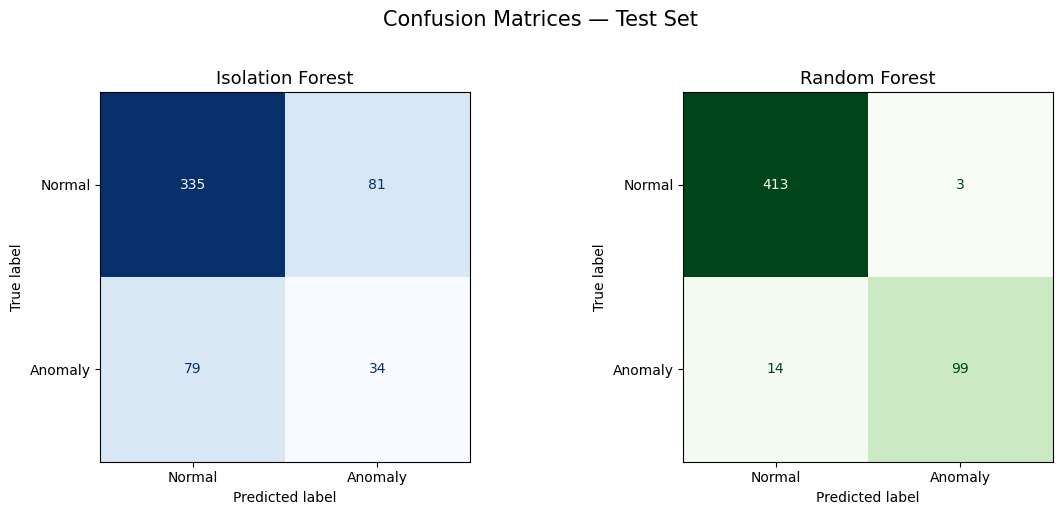

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Compute the raw 2x2 matrices
cm_iso = confusion_matrix(y_test, y_pred_iso)
cm_rf  = confusion_matrix(y_test, y_pred_rf)

# 2. Print TN / FP / FN / TP breakdown for each model
def show_confusion(name, cm):
    tn, fp, fn, tp = cm.ravel()
    print(f"\n--- {name} Confusion Matrix ---")
    print(f"                   Pred Normal   Pred Anomaly")
    print(f"Actual Normal      {tn:>11}   {fp:>12}")
    print(f"Actual Anomaly     {fn:>11}   {tp:>12}")
    print(f"\n  TN = {tn:>5}  (normals correctly kept)")
    print(f"  FP = {fp:>5}  (false alarms)")
    print(f"  FN = {fn:>5}  (anomalies missed)")
    print(f"  TP = {tp:>5}  (anomalies caught)")

show_confusion("Isolation Forest", cm_iso)
show_confusion("Random Forest",    cm_rf)

# 3. Side-by-side heatmap visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm_iso,
    display_labels=['Normal', 'Anomaly']
).plot(ax=axes[0], cmap='Blues', colorbar=False, values_format='d')
axes[0].set_title('Isolation Forest', fontsize=13)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Normal', 'Anomaly']
).plot(ax=axes[1], cmap='Greens', colorbar=False, values_format='d')
axes[1].set_title('Random Forest', fontsize=13)

plt.suptitle('Confusion Matrices — Test Set', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()